In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", context="notebook", palette="deep")

In [2]:
cd ../../

/Users/ann/Documents/Quant finance study/WSQ/quant_project


In [3]:
from src.backtest.backtest import run_backtest_two_param_test
from src.backtest.helpers import results_to_scalar_df

In [4]:
start_ts = '2022-01-01'
end_ts = '2026-02-28'
freq = "4h"

In [5]:
px_parquet_path = f"src/data/px_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets_parquet_path = f"src/data/rets_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"

In [6]:
rets = pd.read_parquet(rets_parquet_path)
px = pd.read_parquet(px_parquet_path)

In [7]:
px = px.loc[:"20241231"]

In [8]:
results_4h = run_backtest_two_param_test(px, freq="4h", rho=0.95, rank_thresh=0.05, alpha=0.5, mkt_tickers=["BTCUSDT", "ETHUSDT"], window_sizes=[i*30*6 for i in range(1, 10)], method="ols")

2026-03-08 20:36:07,118 INFO: Resampled to 4h
mkt_ticker=ETHUSDT: 100%|██████████| 9/9 [00:51<00:00,  5.77s/it]


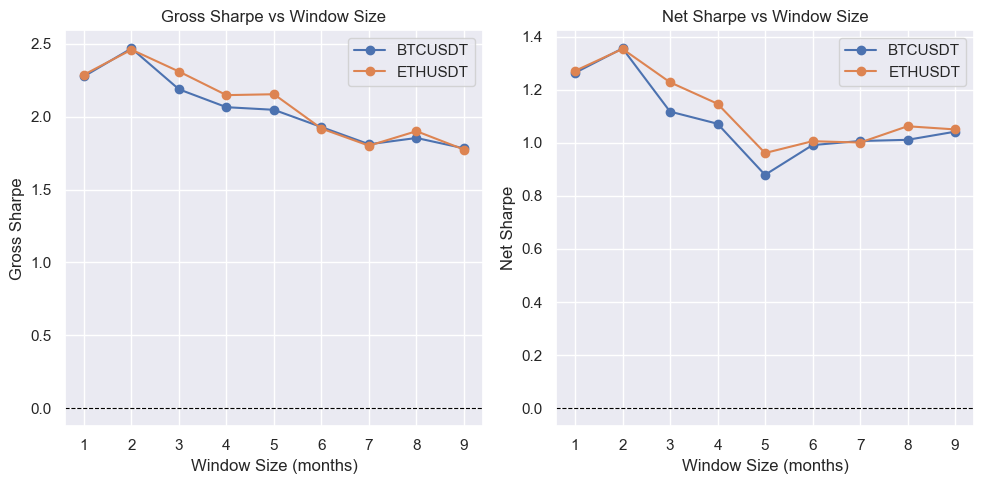

In [9]:
fig, axes = plt.subplots(1,2,figsize=(10,5))

gross_sharpe_df = results_to_scalar_df(results_4h, "gross_sharpe")

net_sharpe_df = results_to_scalar_df(results_4h, "net_sharpe")

gross_sharpe_df.plot(marker="o", ax=axes[0])
net_sharpe_df.plot(marker="o", ax=axes[1])
sharpe_title = ["Gross Sharpe", "Net Sharpe"]
for idx, ax in enumerate(axes):
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Window Size (months)")
    ax.set_ylabel(f"{sharpe_title[idx]}")
    ax.set_title(f"{sharpe_title[idx]} vs Window Size")
plt.tight_layout()
plt.show()

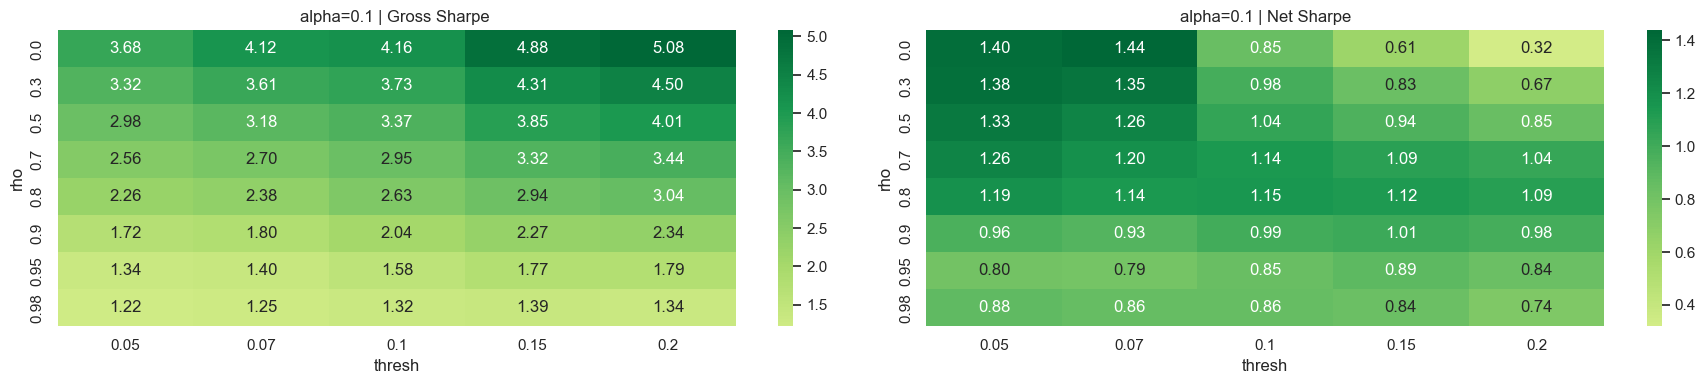

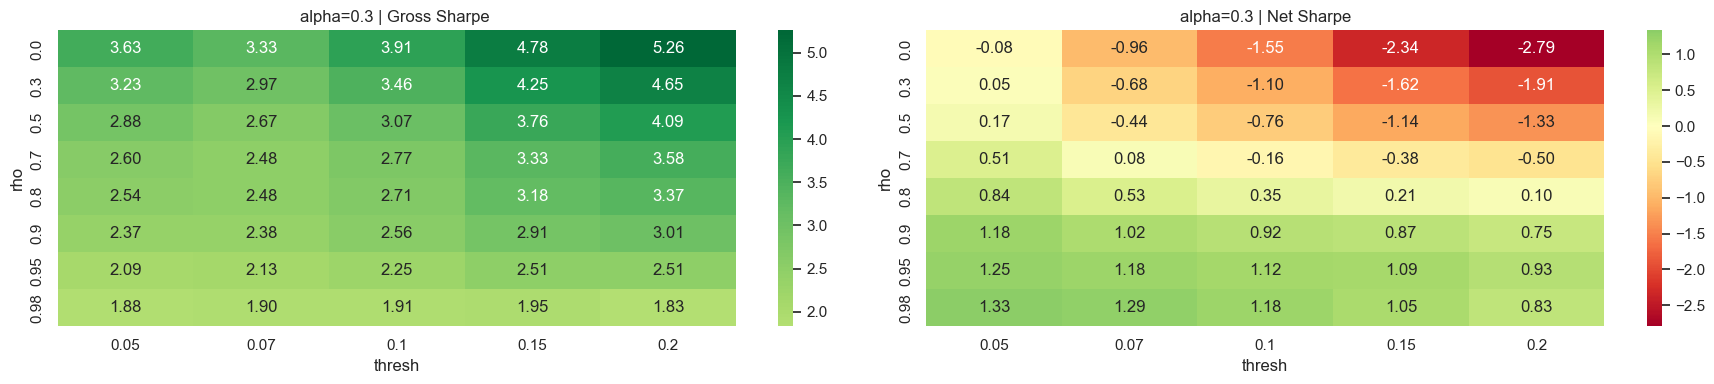

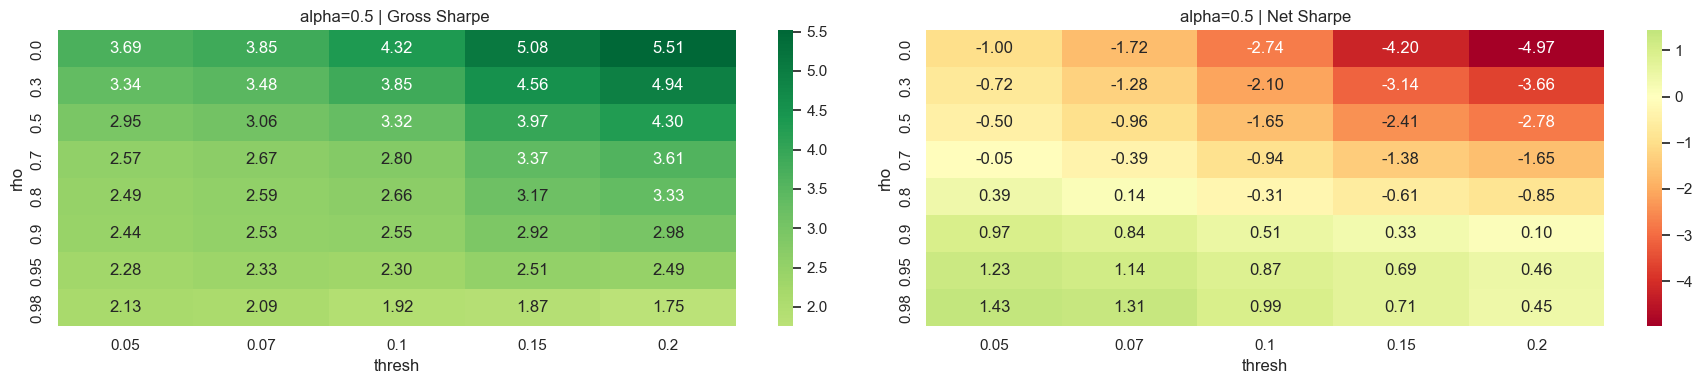

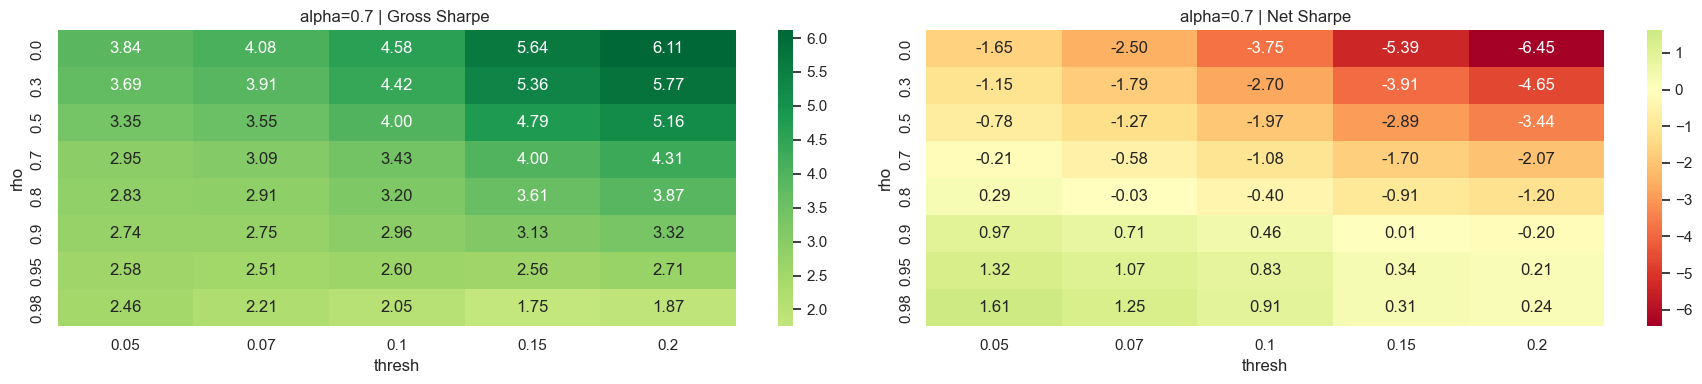

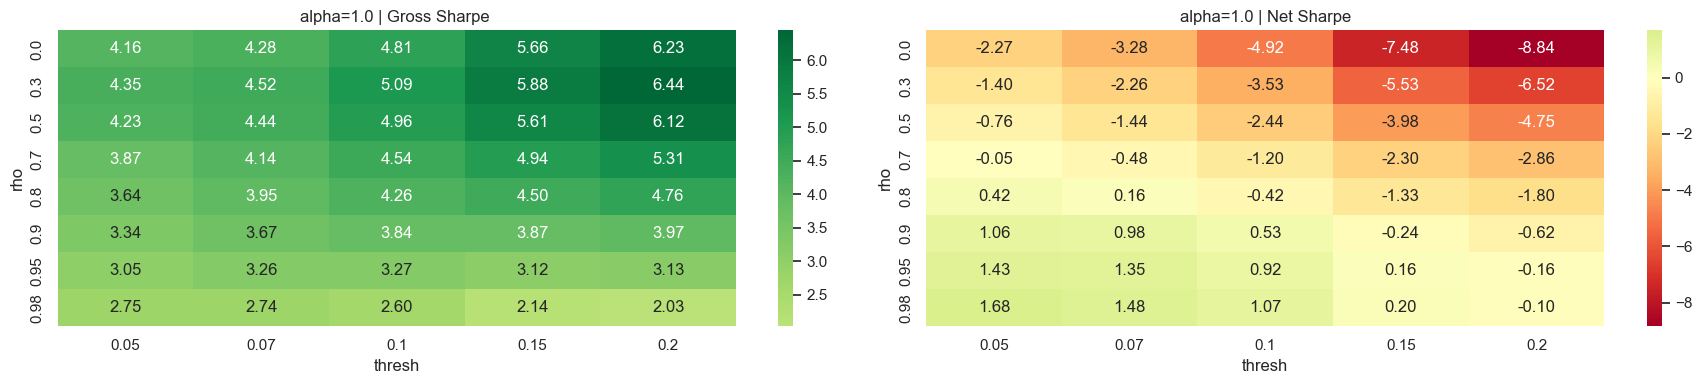

In [10]:
import itertools

from src.backtest.helpers import sharpe

import pandas as pd
from src.ols.ols import calc_resid_ols
from src.signal_construction.transform_signal import transform_signal, dollar_neutral_weights
from src.signal_construction.reduce_trading import partial_adjustment_weights
import seaborn as sns

TCOST_BPS = 20
STRAT_TIME  = 4
BARS_PER_DAY = 24 // STRAT_TIME
window_size = 30 * BARS_PER_DAY
ann_factor = 365 * BARS_PER_DAY

freq=f"{STRAT_TIME}h"
    
px = px.dropna(how="all")      
rets = px.pct_change().dropna(how="all")

resid_df  = calc_resid_ols(rets, window_size=window_size, mkt_ticker="BTCUSDT")

rho_grid   = [0.0, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.98]
thresh_grid = [0.05, 0.07, 0.1, 0.15, 0.2]
alpha_grid  = [0.1, 0.3, 0.5, 0.7, 1.0]  # 1.0 = no smoothing

results_grid = {}

for alpha, rho, thresh in itertools.product(alpha_grid, rho_grid, thresh_grid):
    resid_smoothed = resid_df.ewm(alpha=alpha).mean()

    signal    = transform_signal(-resid_smoothed, how="rank", rank_thresh=thresh)
    w         = dollar_neutral_weights(signal)
    w         = partial_adjustment_weights(w, rho=rho)
    w         = w.sub(w.mean(axis=1), axis=0)

    w_lag     = w.shift(1)
    gross_ret = (w_lag * rets).sum(axis=1)
    to        = (w.fillna(0) - w.shift().fillna(0)).abs().sum(axis=1) / 2
    net_ret   = gross_ret - to * TCOST_BPS * 1e-4
    mid       = gross_ret.index[len(gross_ret)//2]

    results_grid[(alpha, rho, thresh)] = {
        "gross_sharpe": sharpe(gross_ret, ann_factor),
        "net_sharpe":   sharpe(net_ret,   ann_factor),
        "avg_to":       to.mean(),
        "cost_drag":    (to * TCOST_BPS * 1e-4).mean() * ann_factor,
    }

grid_df = pd.DataFrame(results_grid).T
grid_df.index = pd.MultiIndex.from_tuples(grid_df.index, names=["alpha", "rho", "thresh"])


for alpha_val in alpha_grid:
    subset = grid_df.xs(alpha_val, level="alpha")
    net_pivot   = subset["net_sharpe"].unstack("thresh").astype(float)
    gross_pivot = subset["gross_sharpe"].unstack("thresh").astype(float)

    fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    for ax, pivot, title in zip(axes,
        [gross_pivot, net_pivot],
        ["Gross Sharpe ", "Net Sharpe"]):
        sns.heatmap(pivot, annot=True, fmt=".2f", ax=ax, cmap="RdYlGn", center=0)
        ax.set_title(f"alpha={alpha_val} | {title}")
    plt.tight_layout()
    plt.show()


